In [ ]:
from __future__ import annotations

from pathlib import Path

from helpers._helpers import (
    build_panels_paths_generic,
    load_panels_from_paths,
    run_sweeps_for_process_list,
)
import matplotlib.pyplot as plt
import numpy as np

from olbootstrap.online_bootstrap._block_bootstrap import (
    BlockBootstrap,
)
from olbootstrap.online_bootstrap._online_ar_bootstrap import OnlineARBootstrap
from olbootstrap.online_bootstrap._online_gaussian_bootstrap import (
    OnlineGaussianMixtureAsympCSSmoothedBootstrap,
)
from olbootstrap.plotting._plotting import BootstrapPlotter
from olbootstrap.study._study import (
    UniformCoverageStudy,
)
from olbootstrap.synthetic_time_series._ar1 import AR1Process
from olbootstrap.synthetic_time_series._garch import GARCH11Process

/opt/anaconda3/envs/bootstrap/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
exp_kwargs_overrides = [
    {
        "bootstrap_cls": OnlineARBootstrap,
        "method_label": "ARmmult",
        "transform": "student",
    },
    {
        "bootstrap_cls": OnlineGaussianMixtureAsympCSSmoothedBootstrap,
        "method_label": "GaussMix",
        "transform": "student",
    },
    {
        "bootstrap_cls": OnlineARBootstrap,
        "method_label": "ARmrho0",
        "rho_power": 0.0,
        "transform": "gauss",
    },
    {
        "bootstrap_cls": BlockBootstrap,
        "method_label": "Block",
        "transform": "student",
    },
]

In [50]:
def make_sparse_ar20(total_mass: float = 0.6) -> np.ndarray:
    """Sparse AR(20) with 5 nonzero coefficients.

    The nonzero lags are 1, 2, 5, 10, and 20.
    The coefficients sum to `total_mass`.
    """
    phi = np.zeros(20, dtype=float)

    nonzero_lags = np.array([0, 1, 4, 9, 19])
    weights = np.array([0.35, 0.25, 0.20, 0.12, 0.08])
    weights = weights / weights.sum()

    phi[nonzero_lags] = float(total_mass) * weights
    return phi


outdir = Path("..") / "experiments"
outdir.mkdir(parents=True, exist_ok=True)

seed_master = 1234

sample_size = 3500
smoothing_grid = [2 / 10, 2 / 20, 2 / 50, 2 / 100, 2 / 250]
n_series = 150
burn_in = 500
var_warmup = 400

panel_names = [
    "Sine-GARCH",
    "Sparse AR20",
    "Structural breaks",
]


def make_panel_processes(panel_name: str, seed_base: int):
    processes = []
    labels = []

    if panel_name == "Sine-GARCH":
        rng = np.random.default_rng(seed_base)

        persistence = 0.98
        alpha_garch = 0.08
        beta_garch = persistence - alpha_garch
        target_var = 1.0
        omega_garch = (1.0 - persistence) * target_var

        proc = GARCH11Process(
            mean=0.0,
            omega=omega_garch,
            alpha=alpha_garch,
            beta=beta_garch,
            noise_std=1.0,
            noise_dist="normal",
            trend_slope=0.0,
            seasonal_amplitude=1.5,
            seasonal_period=400,
            seasonal_phase=0.0,
            shock_type="none",
            rng=rng,
            nonlinear_sin=True,
            nonlinear_coef=0.8,
        )

        processes.append(proc)
        labels.append("sine-GARCH")
        return processes, labels

    if panel_name == "Sparse AR20":
        rng = np.random.default_rng(seed_base)

        phi_ar20 = make_sparse_ar20(total_mass=0.45)

        proc = AR1Process(
            mean=0.0,
            phi=phi_ar20,
            noise_std=1.0,
            trend_slope=1e-6,
            quadratic_trend=True,
            seasonal_amplitude=0.0,
            seasonal_period=None,
            seasonal_phase=0.0,
            shock_type="permanent",
            jump_prob=0.01,
            jump_scale=2.0,
            rng=rng,
        )

        processes.append(proc)
        labels.append("sparse AR(20)")
        return processes, labels

    if panel_name == "Structural breaks":
        rng = np.random.default_rng(seed_base)

        proc = AR1Process(
            mean=0.0,
            phi=0.45,
            noise_std=1.0,
            trend_slope=0.002,
            seasonal_amplitude=0.0,
            seasonal_period=None,
            seasonal_phase=0.0,
            shock_type="none",
            structural_break=True,
            n_structural_breaks=2,
            break_margin=500,
            min_break_distance=600,
            structural_break_jump_sizes=[3.0, -3.0],
            positive_trend_noise_scale=0.7,
            negative_trend_noise_scale=1.6,
            rng=rng,
        )

        processes.append(proc)
        labels.append("3 random breaks")
        return processes, labels

    raise ValueError(f"Unknown panel: {panel_name}")


setups = [
    ("ewma", 0.1),
]

for setup_idx, (smooth_method, alpha) in enumerate(setups):
    base_exp_kwargs = {
        "B": 200,
        "record_every": 1,
        "smoothing_method": smooth_method,
    }

    setup_dir = outdir / "rebuttal_processes"
    setup_dir.mkdir(parents=True, exist_ok=True)

    for panel_idx, panel_name in enumerate(panel_names):
        seed_base = seed_master + 10_000 * setup_idx + 1_000 * panel_idx

        processes, labels = make_panel_processes(
            panel_name=panel_name,
            seed_base=seed_base,
        )

        _ = run_sweeps_for_process_list(
            processes,
            labels=labels,
            outdir=setup_dir / panel_name,
            seed=seed_master + 100 * setup_idx + panel_idx,
            sample_size=sample_size,
            smoothing_grid=smoothing_grid,
            n_series=n_series,
            burn_in=burn_in,
            alpha=alpha,
            var_warmup=var_warmup,
            base_exp_kwargs=base_exp_kwargs,
            exp_kwargs_overrides=exp_kwargs_overrides,
            progress=True,
            parallel=True,
            n_jobs=-1,
        )

print("Done. Results saved under:", outdir.resolve())

[run_sweeps_for_process_list] Running sweeps for sine-GARCH -> ../experiments/rebuttal_processes/Sine-GARCH/sine-GARCH


combo runs:   0%|          | 0/1 [00:00<?, ?it/s][Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed: 64.2min remaining: 96.4min
[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed: 64.5min remaining: 43.0min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed: 65.1min finished
combo runs: 100%|██████████| 1/1 [1:05:04<00:00, 3904.07s/it]


[run_sweeps_for_process_list] Running sweeps for sparse AR(20) -> ../experiments/rebuttal_processes/Sparse AR20/sparse AR(20)


combo runs:   0%|          | 0/1 [00:00<?, ?it/s][Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed: 65.7min remaining: 98.6min
[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed: 65.9min remaining: 44.0min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed: 66.2min finished
combo runs: 100%|██████████| 1/1 [1:06:12<00:00, 3972.65s/it]


[run_sweeps_for_process_list] Running sweeps for 3 random breaks -> ../experiments/rebuttal_processes/Structural breaks/3 random breaks


combo runs:   0%|          | 0/1 [00:00<?, ?it/s][Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed: 64.0min remaining: 96.0min
[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed: 64.1min remaining: 42.8min
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed: 64.7min finished
combo runs: 100%|██████████| 1/1 [1:04:39<00:00, 3879.72s/it]

Done. Results saved under: /Users/toby/bootstrap/experiments


In [3]:
from typing import Dict


def build_rebuttal_panels_paths(
    root: Path,
    panel_specs: Dict[str, dict],
    methods: list[tuple[str, str]],
    method_display: dict,
    *,
    smooth: str,
    alpha: str | float,
    bi: int,
    vw: int,
    n: int,
    nseries: int,
    B: int,
    nosmooth_var: bool = True,
    include_method_token: bool = True,
) -> Dict[str, dict]:
    """Build paths for rebuttal-process experiments."""
    alpha_str = str(alpha).replace(".", "p")
    panels_paths: Dict[str, dict] = {}

    for panel_title, spec in panel_specs.items():
        panel_dir = root / spec["folder"]

        paths = []
        labels = []

        for method_key, transform_key in methods:
            method_label = method_display.get(method_key, method_key)

            tokens = [
                f"smooth-{smooth}",
                f"tr-{transform_key}",
                f"bi-{bi}",
                f"vw-{vw}",
                f"alpha-{alpha_str}",
                f"n-{n}",
                f"nseries-{nseries}",
                f"B-{B}",
            ]

            if nosmooth_var:
                tokens.append("nosmooth-var")

            if include_method_token:
                tokens.append(f"method-{method_key}")

            tokens.extend(spec.get("must_have", []))

            candidates = [
                p
                for p in panel_dir.rglob("*.npz")
                if all(tok in p.name for tok in tokens)
            ]

            if len(candidates) == 0:
                print(
                    f"[WARN] No file found for panel='{panel_title}', "
                    f"method='{method_key}' in {panel_dir}"
                )
                print("       Required tokens:", tokens)
                continue

            candidates = sorted(candidates, key=lambda p: p.stat().st_mtime)
            chosen = candidates[-1]

            if len(candidates) > 1:
                print(
                    f"[INFO] Multiple matches for panel='{panel_title}', "
                    f"method='{method_key}'. Taking newest:\n  {chosen}"
                )

            paths.append(chosen)
            labels.append(method_label)

        panels_paths[panel_title] = {
            "paths": paths,
            "labels": labels,
        }

    return panels_paths

In [4]:
base = Path("..") / "experiments"
root = base / "rebuttal_processes"

panel_specs_rebuttal = {
    "Sine-GARCH": {
        "folder": "Sine-GARCH",
        "must_have": [
            "garch",
            "seaA-1p5",
            "seaP-400",
        ],
    },
    "Sparse AR(20)": {
        "folder": "Sparse AR20",
        "must_have": [
            "ar20-nz5-mass0p45",
            "trend-1em06",
            "shock-type-permanent_p-0p01_scale-2",
        ],
    },
    "Structural breaks": {
        "folder": "Structural breaks",
        "must_have": [
            "phi-0p45",
            "trend-0p002",
            "shock-type-none_p-0_scale-1",
        ],
    },
}

methods = [
    ("ARmmult", "student"),
    ("ARmrho0", "gauss"),
    ("GaussMix", "student"),
    ("Block", "student"),
]

method_display = {
    "ARmmult": "ours",
    "ARmrho0": "iid",
    "GaussMix": "WS",
    "Block": "block",
}

panels_paths_rebuttal = build_rebuttal_panels_paths(
    root=root,
    panel_specs=panel_specs_rebuttal,
    methods=methods,
    method_display=method_display,
    smooth="ewma",
    alpha="0.1",
    bi=500,
    vw=400,
    n=3500,
    nseries=150,
    B=200,
    nosmooth_var=True,
)

for panel, entry in panels_paths_rebuttal.items():
    print(f"\n{panel}")
    for label, path in zip(entry["labels"], entry["paths"]):
        print(f"  {label}: {path}")

panels_rebuttal = load_panels_from_paths(
    panels_paths_rebuttal,
    loader=UniformCoverageStudy.load_sweep,
)


Sine-GARCH
  ours: ../experiments/rebuttal_processes/Sine-GARCH/sine-GARCH/proc-GARCH11Process__garch__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__nosmooth-var__method-ARmmult__seaA-1p5__seaP-400.npz
  iid: ../experiments/rebuttal_processes/Sine-GARCH/sine-GARCH/proc-GARCH11Process__garch__smooth-ewma__tr-gauss__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__nosmooth-var__method-ARmrho0__seaA-1p5__seaP-400.npz
  WS: ../experiments/rebuttal_processes/Sine-GARCH/sine-GARCH/proc-GARCH11Process__garch__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__nosmooth-var__method-GaussMix__seaA-1p5__seaP-400.npz
  block: ../experiments/rebuttal_processes/Sine-GARCH/sine-GARCH/proc-GARCH11Process__garch__smooth-ewma__tr-student__bi-500__vw-400__alpha-0p1__n-3500__nseries-150__B-200__nosmooth-var__method-Block__seaA-1p5__seaP-400.npz

Sparse AR(20)
  ours: ../experiments/rebuttal_processes/Sparse AR20/sparse AR(20)/proc-AR1Pr

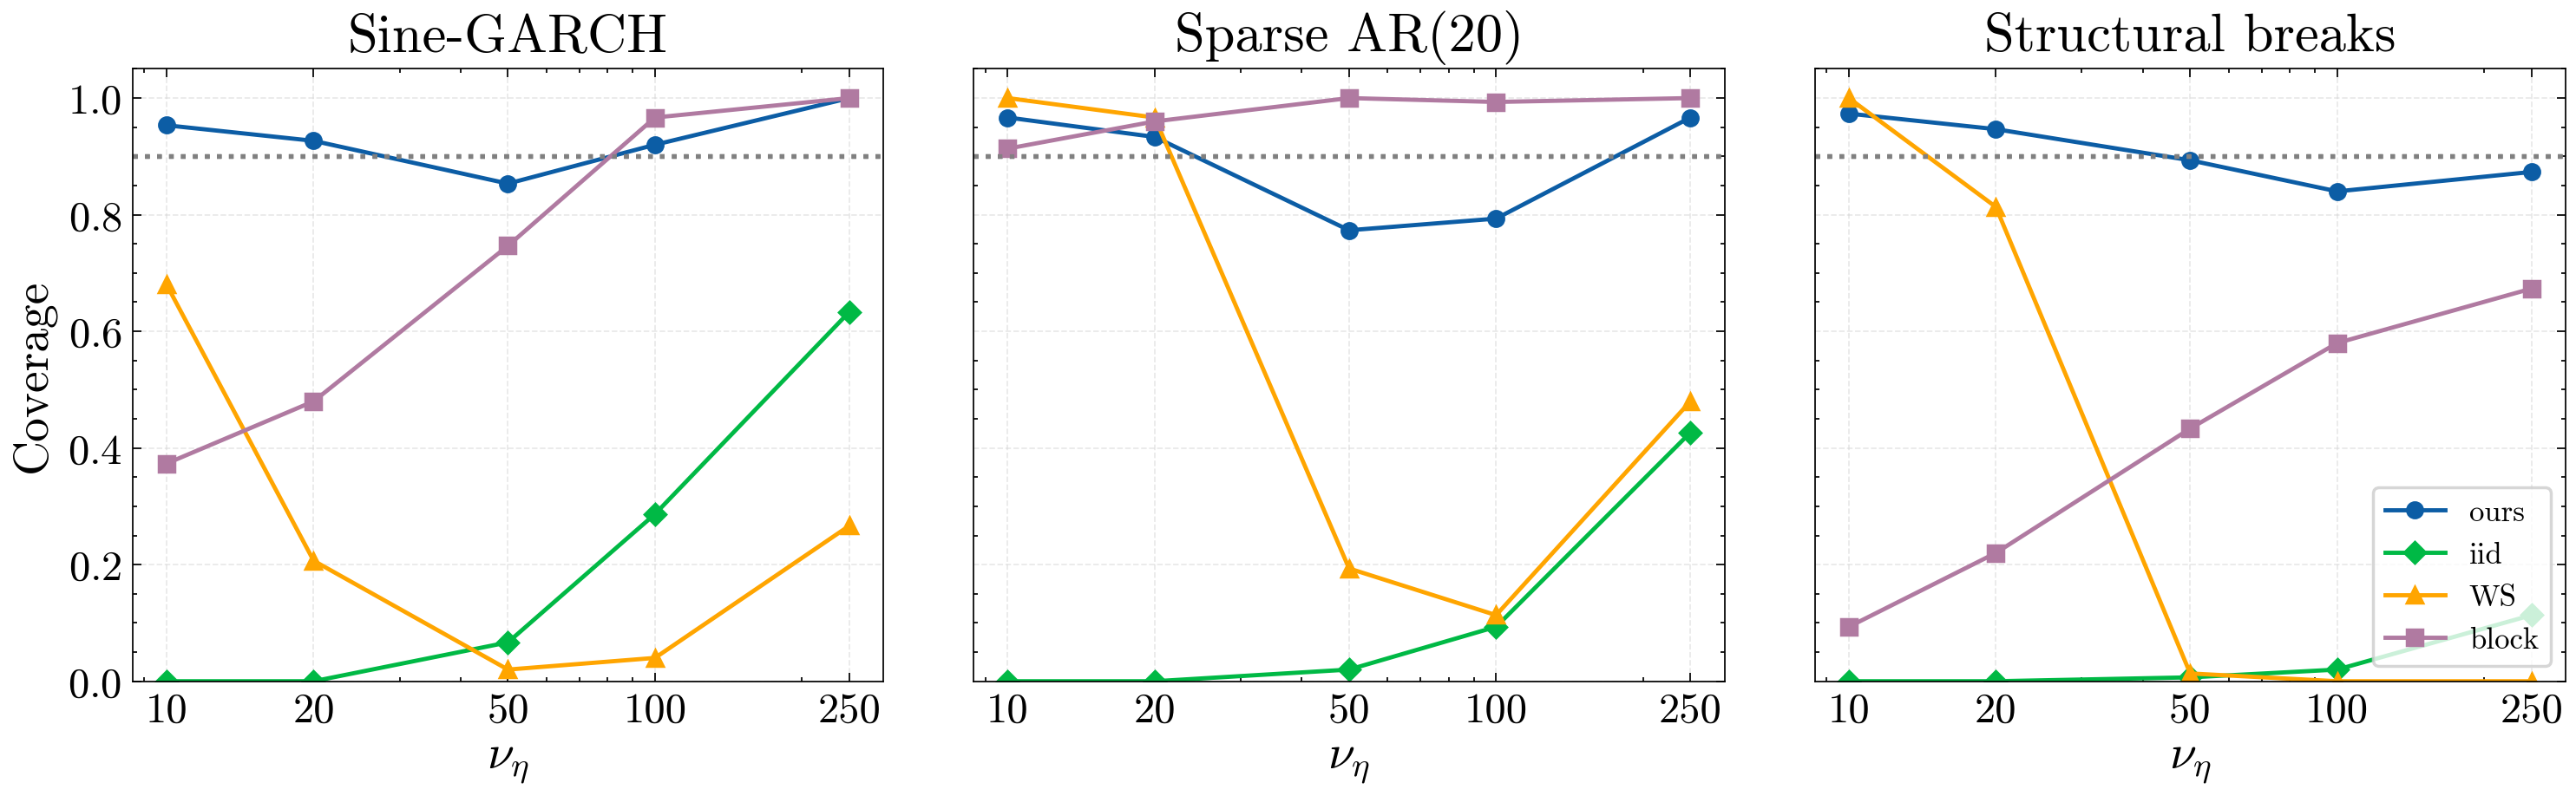

Saved to: /Users/toby/bootstrap/notebooks/figs/sweep_overlay_grid_ewma_alpha01_rebuttal_ours.pdf


In [5]:
outdir = Path("figs")
outdir.mkdir(parents=True, exist_ok=True)
save_path = outdir / "sweep_overlay_grid_ewma_alpha01_rebuttal_ours.pdf"

plotter = BootstrapPlotter(style="science", figsize=(12, 3.4), dpi=250)

fig, axes, _ = plotter.plot_sweep_overlay_grid(
    panels_rebuttal,
    order=["Sine-GARCH", "Sparse AR(20)", "Structural breaks"],
    layout=(1, 3),
    label_left_only=True,
    plot_both=False,
    metric="uniform_series",
    show_target=True,
    common_legend=True,
    legend_in_panel=True,
    legend_panel_index=-1,
    legend_fontsize=10,
    tick_labelsize=14,
    axis_labelsize=16,
    title_size=18,
    marker_size=5,
    line_width=1.4,
    hspace=0.25,
    wspace=0.12,
    save_path=save_path,
    log_eta=True,
    style_by_method=True,
    method_from_label="last_token",
    method_order=["ours", "block", "WS", "iid"],
    method_colors={
        "ours": "#0C5DA5",
        "block": "#B07AA1",
        "WS": "orange",
        "iid": "#00B945",
    },
    ess=True,
)

plt.show()
print("Saved to:", save_path.resolve())

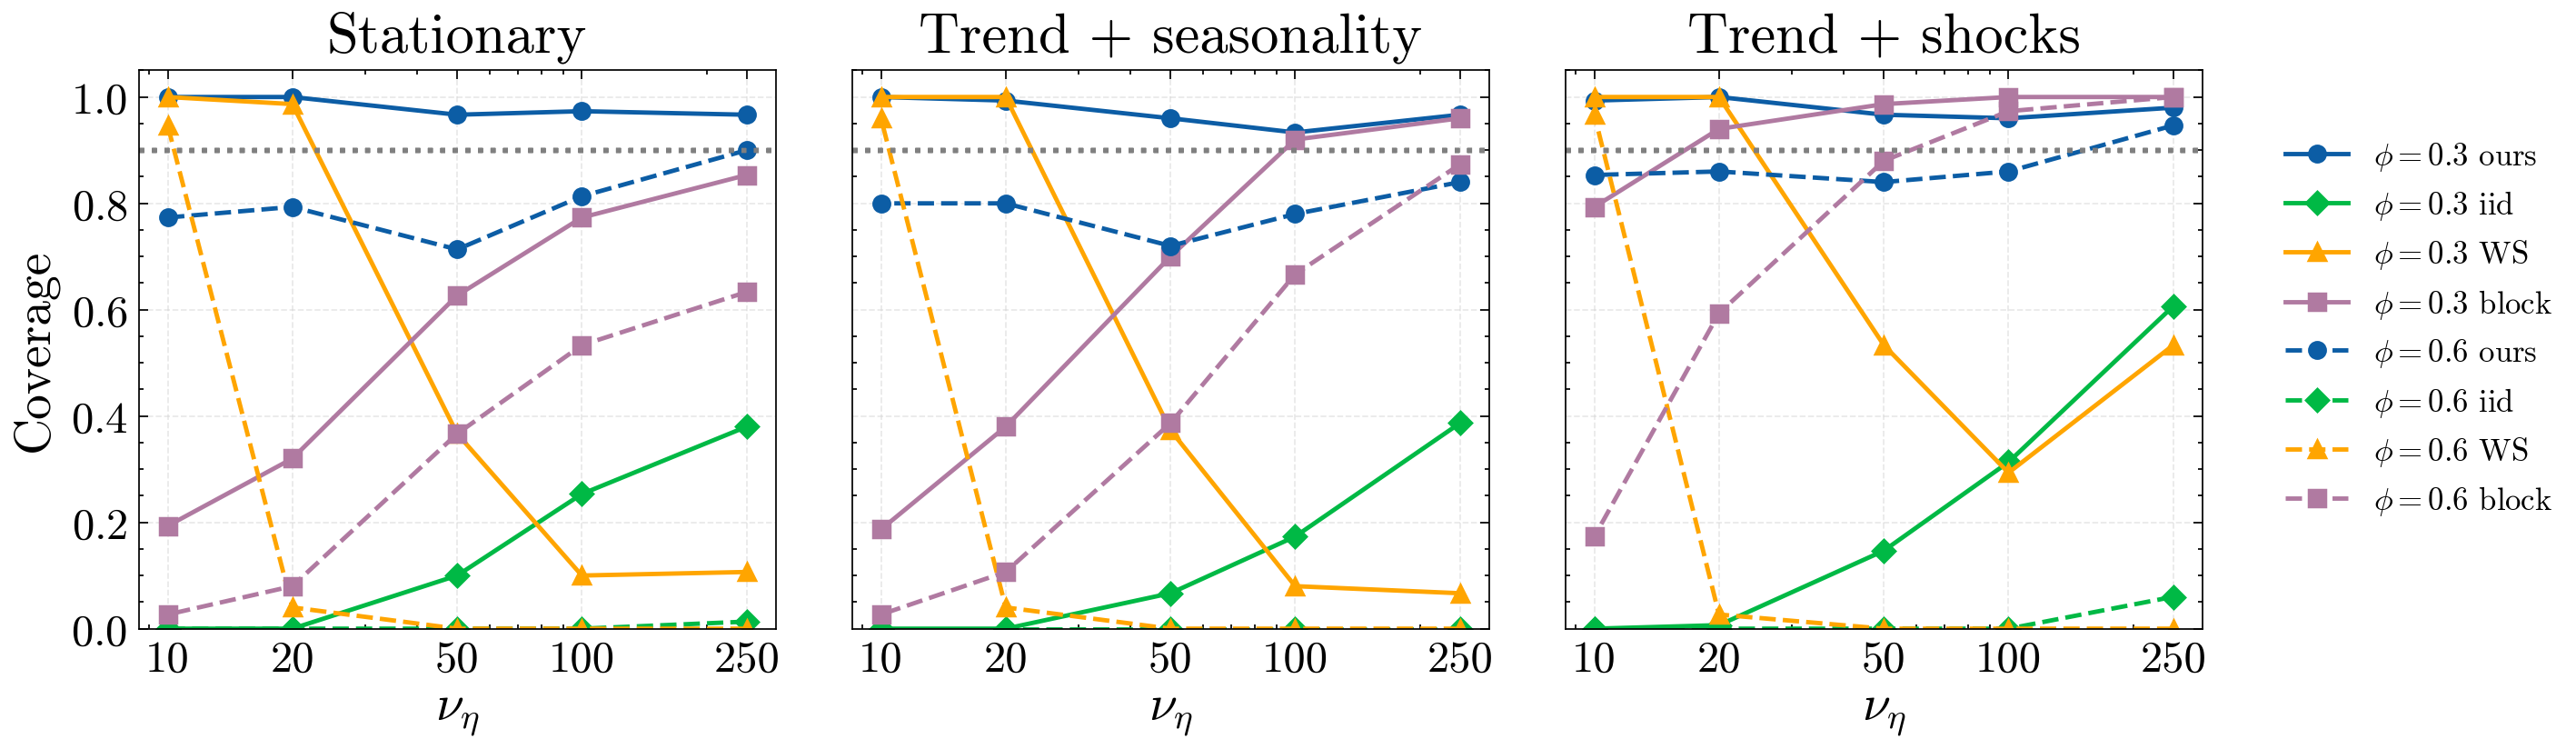

Saved to: /Users/toby/bootstrap/notebooks/figs/sweep_overlay_grid_ewma_alpha01_block.pdf


In [8]:
base = Path("..") / "experiments"

root = base / "smooth-ewma_alpha-0p1"
panel_specs_main = {
    "Stationary": {"shock": "__shock-type-none_p-0_scale-1"},
    "Trend + seasonality": {
        "shock": "__shock-type-none_p-0_scale-1",
        "tail": "__trend-0p001__seaA-0p4__seaP-400",
    },
    "Trend + shocks": {
        "shock": "__shock-type-permanent_p-0p005_scale-2",
        "tail": "__trend-0p001",
    },
}
phis = {"0.3": r"$\phi=0.3$", "0.6": r"$\phi=0.6$"}
# phis = {"0.3": r"$\phi=0.3$"}
methods = [
    ("ARmmult", "student"),
    ("ARmrho0", "gauss"),
    ("GaussMix", "student"),
    ("Block", "student"),
]
method_display = {
    "ARmmult": "ours",
    "GaussMix": "WS",
    "ARmrho0": "iid",
    "Block": "block",
}
# method_display = {"ARmmult": "ours", "Block": "block"}

panels_paths = build_panels_paths_generic(
    root=root,
    phis=phis,
    methods=methods,
    method_display=method_display,
    panel_specs=panel_specs_main,
    smooth="ewma",
    alpha="0.1",
    bi=500,
    vw=400,
    n=3500,
    nseries=150,
    B=400,
    nosmooth_var=True,
    sweep_prefix=False,
    include_method_token=True,
)

panels_ewma_a01 = load_panels_from_paths(
    panels_paths, loader=UniformCoverageStudy.load_sweep
)

outdir = Path("figs")
outdir.mkdir(parents=True, exist_ok=True)
save_path = outdir / "sweep_overlay_grid_ewma_alpha01_block.pdf"

plotter = BootstrapPlotter(style="science", figsize=(12, 3), dpi=250)
fig, axes, _ = plotter.plot_sweep_overlay_grid(
    panels_ewma_a01,
    order=[
        "Stationary",
        "Trend + seasonality",
        "Trend + shocks",
    ],  # only plot one panel since we only have one
    layout=(1, 3),
    label_left_only=True,
    plot_both=False,
    metric="uniform_series",
    show_target=True,
    common_legend=True,
    legend_in_panel=False,
    legend_outside_right=True,
    legend_panel_index=-1,
    legend_fontsize=10,
    tick_labelsize=14,
    axis_labelsize=16,
    title_size=18,
    marker_size=5,
    line_width=1.4,
    hspace=0.25,
    wspace=0.12,
    save_path=save_path,
    log_eta=True,
    style_by_method=True,
    method_from_label="last_token",
    method_order=["ours", "block", "WS", "iid"],
    method_colors={
        "ours": "#0C5DA5",
        "block": "#B07AA1",
        "WS": "orange",
        "iid": "#00B945",
    },
    ess=True,
)

plt.show()

print("Saved to:", save_path.resolve())

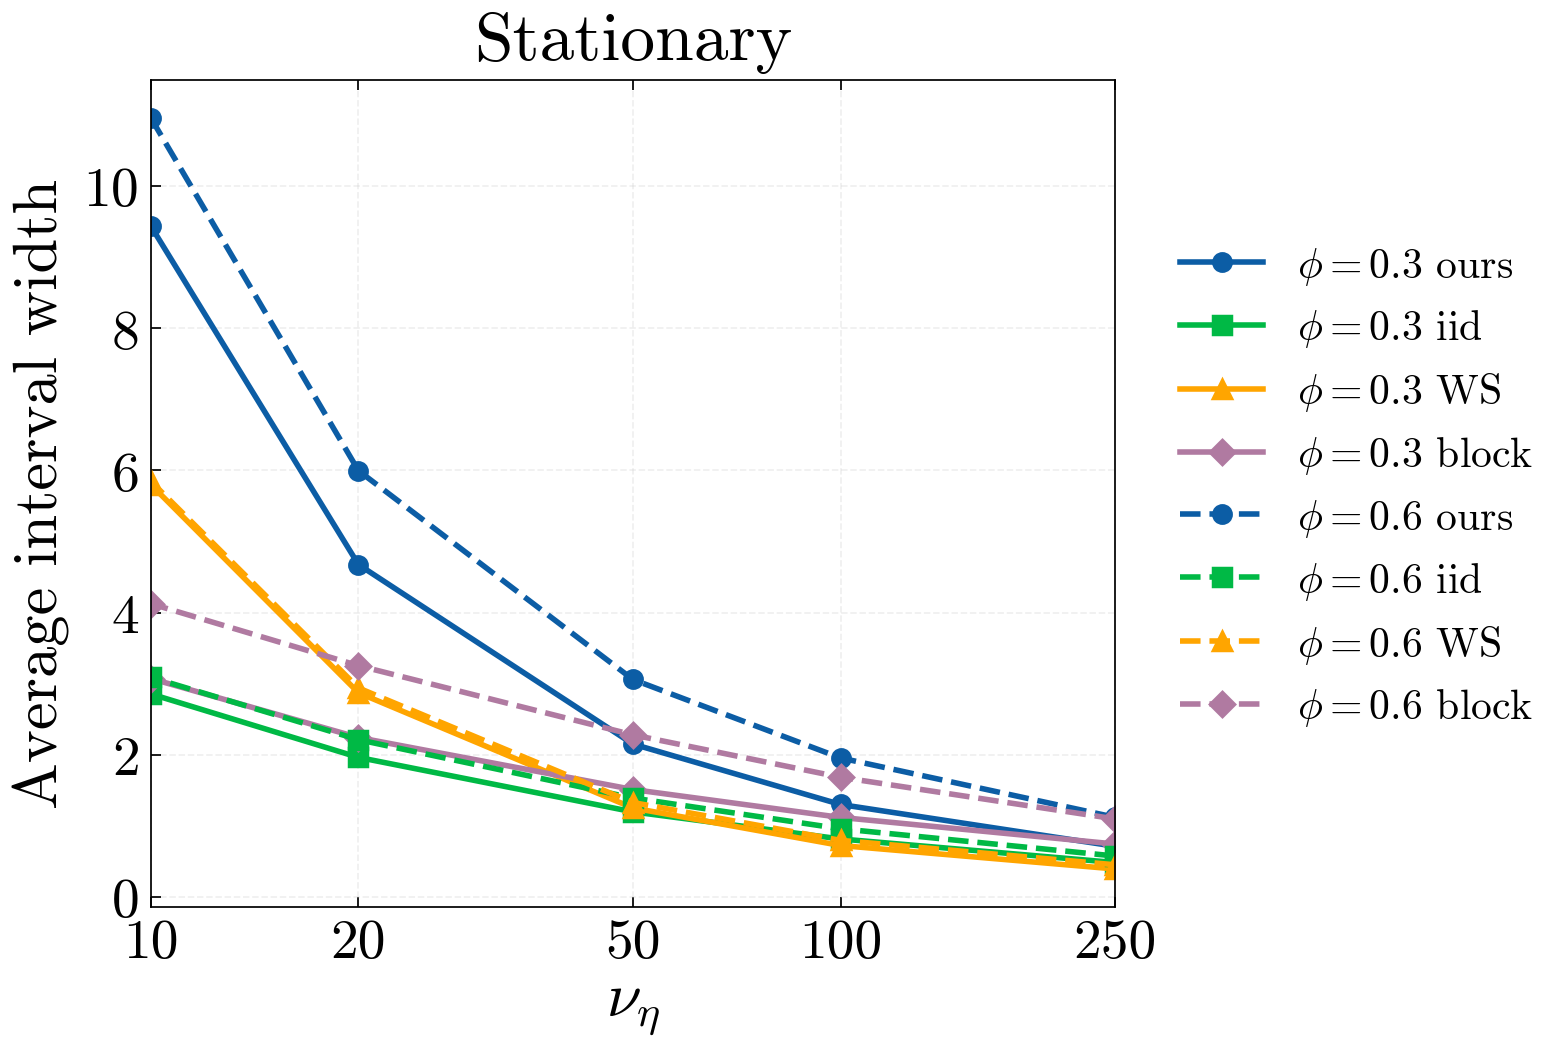

In [ ]:
plotter = BootstrapPlotter(style="science", figsize=(8, 4), dpi=250)

stationary_panels = {"Stationary": panels_ewma_a01["Stationary"]}

fig_stat, ax_stat = plotter.plot_avg_uniform_width_grid(
    stationary_panels,
    order=["Stationary"],
    layout=(1, 1),
    figsize=(5.5, 4),
    marker_size=5,
    line_width=1.6,
    hspace=0.25,
    legend_fontsize=12,
    tick_labelsize=16,
    axis_labelsize=18,
    title_size=20,
    save_path=Path("figs/avg_uniform_widths_stationary_final.pdf"),
    show=True,
    legend_inside_bottom_right=False,
    legend_outside_right=True,
    legend_loc="inplot-br",
    log_eta=True,
    style_by_method=True,
    method_from_label="last_token",
    method_order=["ours", "iid", "WS"],
    ess=True,
)

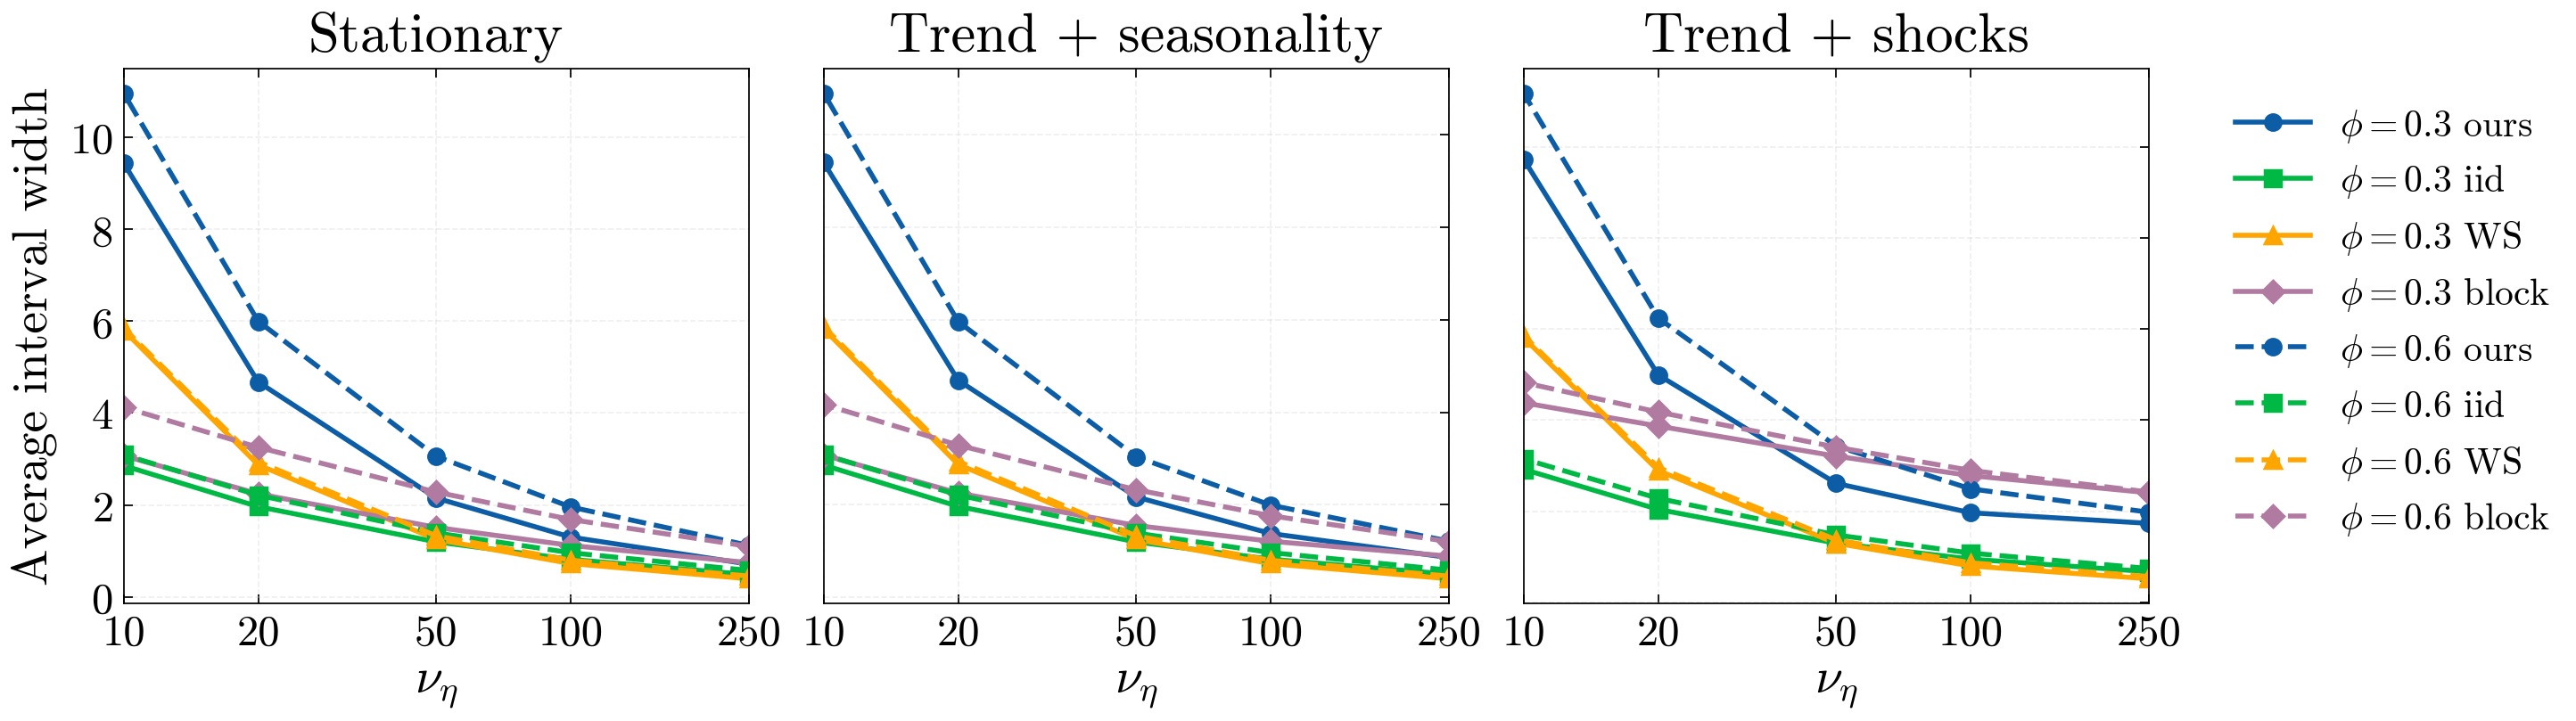

In [9]:
other_order = ["Stationary", "Trend + seasonality", "Trend + shocks"]
other_panels = {k: panels_ewma_a01[k] for k in other_order}

fig_trends, axes_trends = plotter.plot_avg_uniform_width_grid(
    other_panels,
    order=other_order,
    dpi=250,
    layout=(1, 3),
    figsize=(12, 3),
    marker_size=5,
    line_width=1.6,
    hspace=0.25,
    legend_fontsize=12,
    axis_labelsize=16,
    tick_labelsize=14,
    title_size=18,
    save_path=Path("figs/avg_uniform_widths_block.pdf"),
    show=True,
    legend_inside_bottom_right=False,
    legend_outside_right=True,
    legend_loc="inplot-br",
    log_eta=True,
    log_y=False,
    style_by_method=True,
    method_from_label="last_token",
    method_order=["ours", "iid", "WS", "block"],
    method_colors={
        "ours": "#0C5DA5",
        "block": "#B07AA1",
    },
    ess=True,
)